In [1]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy import sparse, stats
from scipy.stats import pearsonr, ttest_rel, ttest_1samp, wilcoxon

from sklearn.linear_model import RidgeCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

import pyranges as pr
import gzip

# ── Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.titlesize': 13, 'axes.labelsize': 11})
sc.settings.verbosity = 1

# ── File paths (adjust to your environment)
DATA_PATH = "/geode2/home/u030/gkarutur/Quartz/regression/data/10k_PBMC_Multiome_nextgem_Chromium_X_filtered_feature_bc_matrix.h5"
GTF_PATH  = "/geode2/home/u030/gkarutur/Quartz/regression/data/gencode.v38.annotation.gtf.gz"

# ── Regression config
TEST_SIZE             = 0.20
CV_FOLDS              = 5
ALPHAS                = np.logspace(-3, 4, 30)
MIN_PEAKS             = 3      # Genes with <3 cis-peaks are unmodelable; dropped
MAX_PEAKS             = 500    # Hard cap; top-variance peaks selected if exceeded
N_PERMUT              = 100    # Number of permutations for null R² distribution
CIS_BP                = 100_000  # ±100 kb cis-window (captures most cis-eQTLs in PBMC)
MIN_CELLS_PER_CLUSTER = 30     # Pseudobulk: min cells per cluster for stable aggregation
TOP_K_GENES           = 1000   # Top variable genes for regression

print("All imports successful.")
print(f"Cis-window: ±{CIS_BP:,} bp | Min peaks/gene: {MIN_PEAKS} | Max peaks/gene: {MAX_PEAKS}")
print(f"Permutations: {N_PERMUT} | Top genes: {TOP_K_GENES}")


All imports successful.
Cis-window: ±100,000 bp | Min peaks/gene: 3 | Max peaks/gene: 500
Permutations: 100 | Top genes: 1000


In [2]:
adata_combined = sc.read_10x_h5(DATA_PATH, gex_only=False)
adata_combined.var_names_make_unique()

rna_mask  = adata_combined.var['feature_types'] == 'Gene Expression'
atac_mask = adata_combined.var['feature_types'] == 'Peaks'

rna  = adata_combined[:, rna_mask].copy()
atac = adata_combined[:, atac_mask].copy()

print(f"RNA:  {rna.shape[0]:,} cells × {rna.shape[1]:,} genes")
print(f"ATAC: {atac.shape[0]:,} cells × {atac.shape[1]:,} peaks")


RNA:  10,970 cells × 36,601 genes
ATAC: 10,970 cells × 111,743 peaks


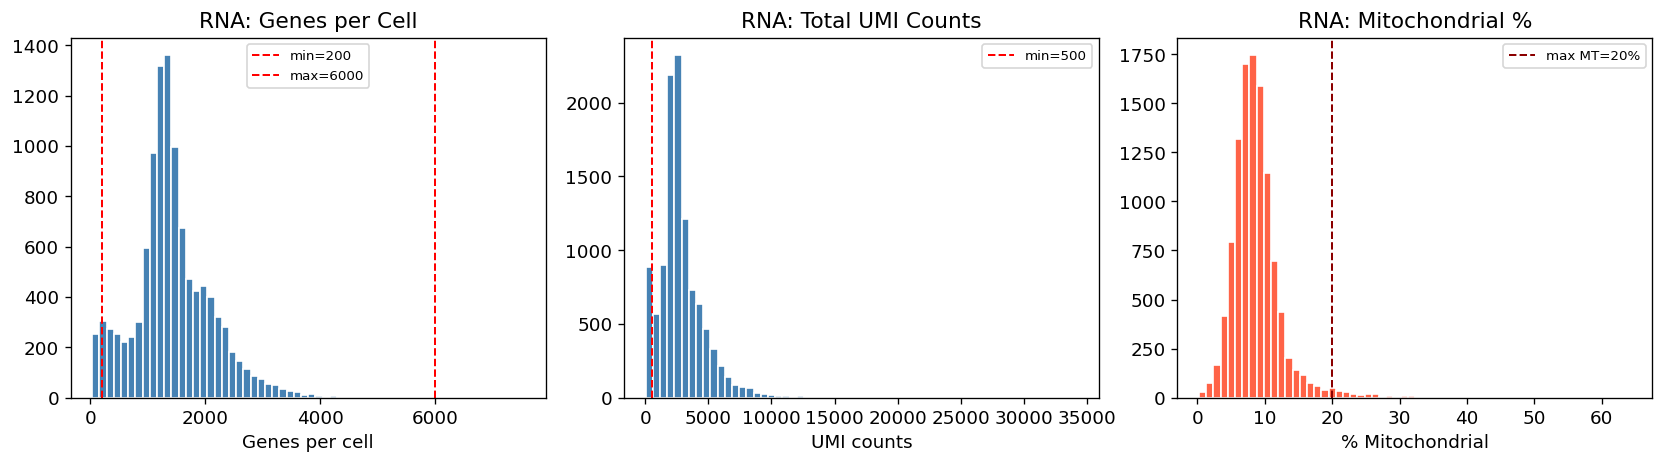

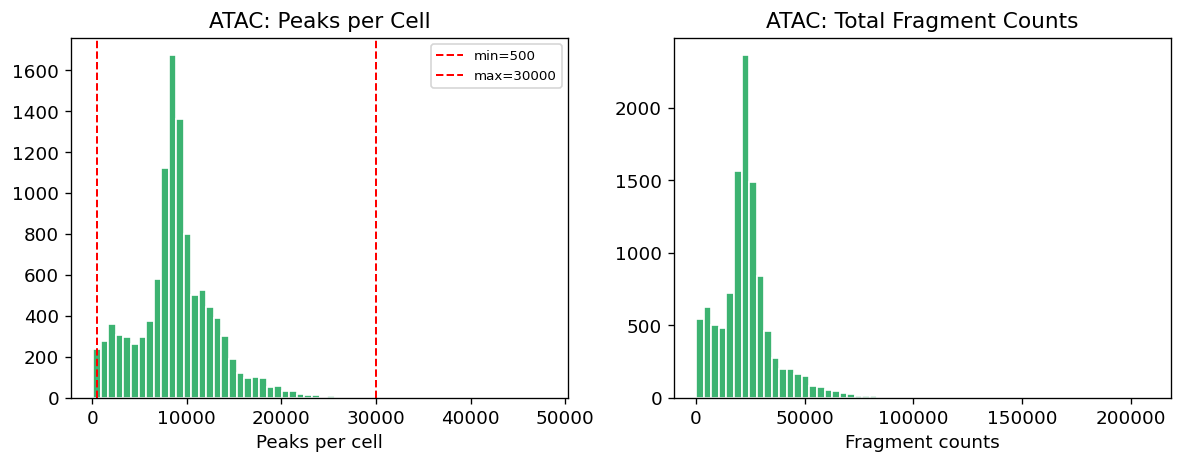

In [3]:
# ── RNA QC metrics
rna.var['mt'] = rna.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(rna, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].hist(rna.obs['n_genes_by_counts'], bins=60, color='steelblue', edgecolor='white')
axes[0].axvline(200,  color='red', ls='--', lw=1.2, label='min=200')
axes[0].axvline(6000, color='red', ls='--', lw=1.2, label='max=6000')
axes[0].set(xlabel='Genes per cell', title='RNA: Genes per Cell'); axes[0].legend(fontsize=8)

axes[1].hist(rna.obs['total_counts'], bins=60, color='steelblue', edgecolor='white')
axes[1].axvline(500, color='red', ls='--', lw=1.2, label='min=500')
axes[1].set(xlabel='UMI counts', title='RNA: Total UMI Counts'); axes[1].legend(fontsize=8)

axes[2].hist(rna.obs['pct_counts_mt'], bins=60, color='tomato', edgecolor='white')
axes[2].axvline(20, color='darkred', ls='--', lw=1.2, label='max MT=20%')
axes[2].set(xlabel='% Mitochondrial', title='RNA: Mitochondrial %'); axes[2].legend(fontsize=8)

plt.tight_layout(); plt.savefig('qc_rna.png', bbox_inches='tight'); plt.show()

# ── ATAC QC metrics
sc.pp.calculate_qc_metrics(atac, percent_top=None, log1p=False, inplace=True)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(atac.obs['n_genes_by_counts'], bins=60, color='mediumseagreen', edgecolor='white')
axes[0].axvline(500,   color='red', ls='--', lw=1.2, label='min=500')
axes[0].axvline(30000, color='red', ls='--', lw=1.2, label='max=30000')
axes[0].set(xlabel='Peaks per cell', title='ATAC: Peaks per Cell'); axes[0].legend(fontsize=8)

axes[1].hist(atac.obs['total_counts'], bins=60, color='mediumseagreen', edgecolor='white')
axes[1].set(xlabel='Fragment counts', title='ATAC: Total Fragment Counts')
plt.tight_layout(); plt.savefig('qc_atac.png', bbox_inches='tight'); plt.show()


In [4]:
rna_keep = (
    (rna.obs['n_genes_by_counts'] >= 200) &
    (rna.obs['n_genes_by_counts'] <= 6000) &
    (rna.obs['total_counts']      >= 500)  &
    (rna.obs['pct_counts_mt']     <= 20)
)
atac_keep = (
    (atac.obs['n_genes_by_counts'] >= 500)  &
    (atac.obs['n_genes_by_counts'] <= 30000)
)
common_cells = rna.obs_names[rna_keep].intersection(atac.obs_names[atac_keep])
rna  = rna[common_cells].copy()
atac = atac[common_cells].copy()

print(f"Cells retained: {len(common_cells):,} / {adata_combined.n_obs:,} "
      f"({100*len(common_cells)/adata_combined.n_obs:.1f}%)")
print(f"RNA:  {rna.shape}  |  ATAC: {atac.shape}")

# Store raw counts before normalization
rna.layers['counts'] = rna.X.copy()
atac.layers['counts'] = atac.X.copy()


Cells retained: 9,994 / 10,970 (91.1%)
RNA:  (9994, 36601)  |  ATAC: (9994, 111743)


Leiden clusters found: 36
Cluster size range: 15–766 cells


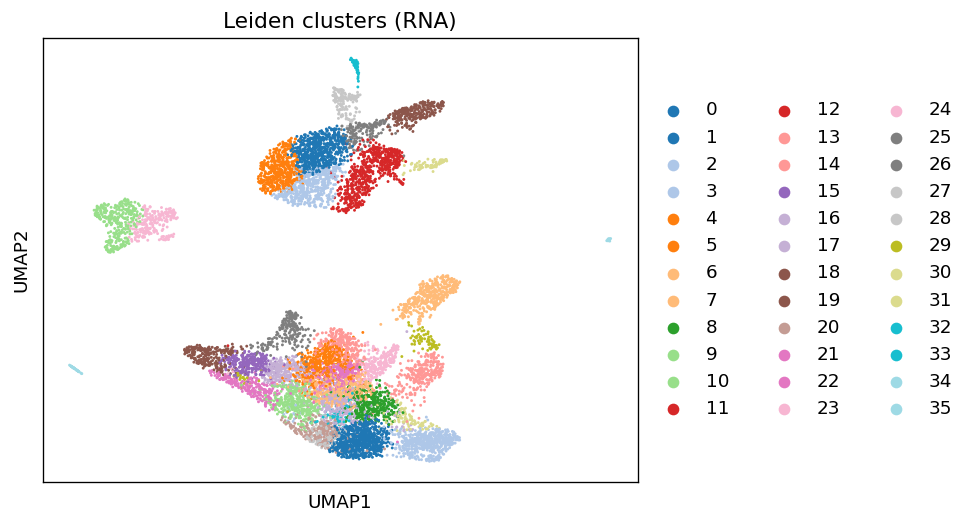

<Figure size 768x576 with 0 Axes>

In [5]:
# ── Normalize & log1p for clustering
rna_clust = rna.copy()
sc.pp.normalize_total(rna_clust, target_sum=1e4)
sc.pp.log1p(rna_clust)
sc.pp.highly_variable_genes(rna_clust, n_top_genes=3000, flavor='seurat')
sc.pp.scale(rna_clust, max_value=10)

# ── PCA → neighbors → UMAP → Leiden
sc.tl.pca(rna_clust, n_comps=30, svd_solver='arpack', random_state=RANDOM_SEED)
sc.pp.neighbors(rna_clust, n_neighbors=15, n_pcs=20, random_state=RANDOM_SEED)
sc.tl.umap(rna_clust, random_state=RANDOM_SEED)
sc.tl.leiden(rna_clust, resolution=2.5, random_state=RANDOM_SEED, key_added='leiden')

# Copy cluster labels back
rna.obs['leiden']  = rna_clust.obs['leiden']
rna.obsm['X_umap'] = rna_clust.obsm['X_umap']
atac.obs['leiden'] = rna_clust.obs['leiden']

cluster_sizes = rna.obs['leiden'].value_counts().sort_index()
print(f"Leiden clusters found: {rna.obs['leiden'].nunique()}")
print(f"Cluster size range: {cluster_sizes.min()}–{cluster_sizes.max()} cells")

sc.pl.umap(rna_clust, color='leiden', palette='tab20',
           title='Leiden clusters (RNA)', save=False)
plt.savefig('umap_clusters.png', bbox_inches='tight', dpi=150)


Marker genes available: 19

Cell type distribution:
Unknown     3547
Monocyte    2667
T cell      2020
NK cell      956
B cell       587
DC           217


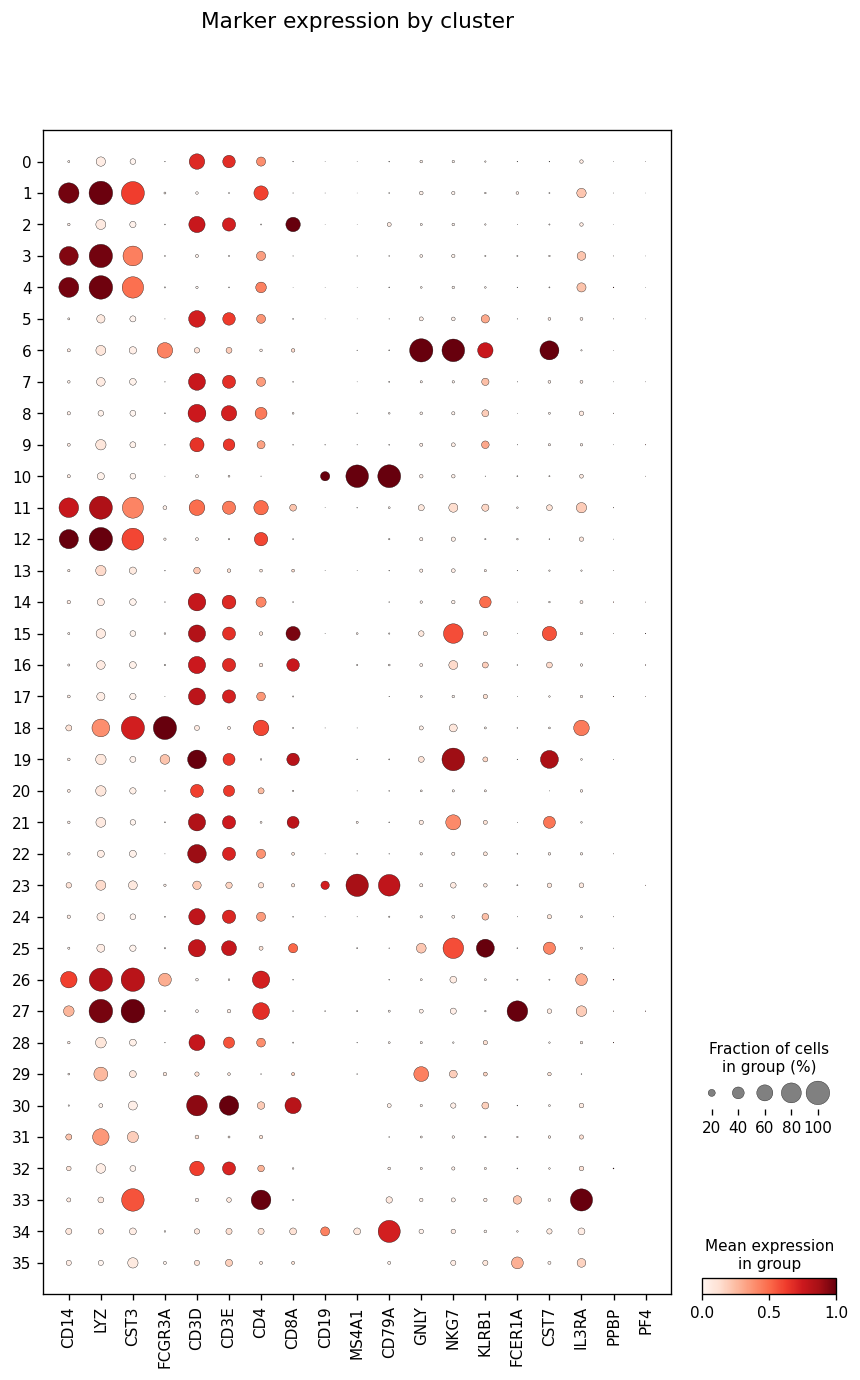

<Figure size 768x576 with 0 Axes>

In [6]:
marker_genes = {
    'Monocyte' : ['CD14', 'LYZ', 'CST3', 'FCGR3A'],
    'T cell'   : ['CD3D', 'CD3E', 'CD4', 'CD8A'],
    'B cell'   : ['CD19', 'MS4A1', 'CD79A'],
    'NK cell'  : ['GNLY', 'NKG7', 'KLRB1'],
    'DC'       : ['FCER1A', 'CST7', 'IL3RA'],
    'Platelet' : ['PPBP', 'PF4'],
}
all_markers = [g for genes in marker_genes.values()
               for g in genes if g in rna_clust.var_names]
print(f"Marker genes available: {len(all_markers)}")

# Score clusters
cluster_means = (sc.get.obs_df(rna_clust, keys=all_markers + ['leiden'])
                   .groupby('leiden').mean())
scores = pd.DataFrame(index=cluster_means.index)
for ct, genes in marker_genes.items():
    g = [x for x in genes if x in cluster_means.columns]
    if g:
        scores[ct] = cluster_means[g].mean(axis=1)

THRESH = 0.2
cluster_annot = {
    cl: (scores.loc[cl].idxmax() if scores.loc[cl].max() >= THRESH else 'Unknown')
    for cl in scores.index
}

rna.obs['cell_type']  = rna.obs['leiden'].map(cluster_annot)
atac.obs['cell_type'] = rna.obs['cell_type']

ct_counts = rna.obs['cell_type'].value_counts()
print("\nCell type distribution:")
print(ct_counts.to_string())

# Dotplot
sc.pl.dotplot(rna_clust, var_names=all_markers, groupby='leiden',
              standard_scale='var', title='Marker expression by cluster', show=True)
plt.savefig('dotplot_markers.png', bbox_inches='tight', dpi=150)


In [7]:
# ── RNA: normalize for regression features
sc.pp.normalize_total(rna, target_sum=1e4)
sc.pp.log1p(rna)

min_cells = int(0.05 * rna.n_obs)
sc.pp.filter_genes(rna, min_cells=min_cells)
print(f"Genes after expression filtering (>5% cells): {rna.n_vars:,}")

# ── ATAC: TF-IDF transform
def tfidf_transform(X, binarize=True):
    """TF-IDF for scATAC-seq (binarized). Standard normalization for accessibility data."""
    X = X.astype(float)
    if binarize:
        X = (X > 0).astype(float)
        if not sparse.issparse(X):
            X = sparse.csr_matrix(X)
    cell_totals = np.array(X.sum(axis=1)).flatten()
    cell_totals[cell_totals == 0] = 1
    TF   = X.multiply(1.0 / cell_totals[:, None]) if sparse.issparse(X) else X / cell_totals[:, None]
    N    = X.shape[0]
    peak_counts = np.array((X > 0).sum(axis=0)).flatten()
    peak_counts[peak_counts == 0] = 1
    IDF  = np.log1p(N / peak_counts)
    TFIDF = TF.multiply(IDF) if sparse.issparse(TF) else TF * IDF
    return TFIDF

atac.X = tfidf_transform(atac.X, binarize=True)
if sparse.issparse(atac.X):
    atac.X = atac.X.tocsc()   # CSC for fast column slicing
print("ATAC TF-IDF transform complete.")
if sparse.issparse(atac.X):
    print(f"  ATAC sparsity: {1 - atac.X.nnz / (atac.shape[0]*atac.shape[1]):.1%}")


Genes after expression filtering (>5% cells): 7,537
ATAC TF-IDF transform complete.
  ATAC sparsity: 91.7%


In [8]:
def parse_peak(name):
    name = name.replace('_', ':', 1).replace('_', '-')
    if ':' in name and '-' in name:
        chrom, rest = name.split(':', 1)
        start, end  = rest.split('-', 1)
        return chrom, int(start), int(end)
    return None, None, None

peak_names = atac.var_names.tolist()
chroms, starts, ends, valid_idx = [], [], [], []
for i, p in enumerate(peak_names):
    c, s, e = parse_peak(p)
    if c is not None:
        chroms.append(c); starts.append(s); ends.append(e); valid_idx.append(i)

peak_df = pd.DataFrame({
    'Chromosome': chroms, 'Start': starts, 'End': ends,
    'peak_idx': valid_idx,
    'peak_name': [peak_names[i] for i in valid_idx]
})
print(f"Parsed peaks: {len(peak_df):,}")

# Load gene TSS from GTF
genes = []
with gzip.open(GTF_PATH, 'rt') as f:
    for line in f:
        if line.startswith('#'): continue
        parts = line.strip().split('\t')
        if parts[2] == 'gene' and 'gene_name "' in parts[8]:
            chrom     = parts[0]
            start     = int(parts[3])
            end       = int(parts[4])
            strand    = parts[6]
            gene_name = parts[8].split('gene_name "')[1].split('"')[0]
            tss       = start if strand == '+' else end
            genes.append([chrom, tss, gene_name])

genes_df = pd.DataFrame(genes, columns=['Chromosome', 'tss', 'gene_name'])
genes_df['cis_start'] = (genes_df['tss'] - CIS_BP).clip(lower=0)
genes_df['cis_end']   =  genes_df['tss'] + CIS_BP
print(f"Genes loaded: {genes_df.shape[0]:,}")
print(f"Cis-window: ±{CIS_BP:,} bp")

# Overlap peaks with cis-windows
peaks_pr = pr.PyRanges(peak_df)
cis_pr   = pr.PyRanges(
    genes_df[['Chromosome','cis_start','cis_end','gene_name','tss']]
    .rename(columns={'cis_start':'Start','cis_end':'End'})
)
overlap    = peaks_pr.join(cis_pr)
overlap_df = overlap.df.dropna(subset=['gene_name'])
overlap_df['peak_center'] = (overlap_df['Start'] + overlap_df['End']) / 2
overlap_df['dist_to_tss'] = (overlap_df['peak_center'] - overlap_df['tss']).abs()

print(f"Peak-cis overlaps (±{CIS_BP//1000} kb): {len(overlap_df):,}")


Parsed peaks: 111,743
Genes loaded: 60,649
Cis-window: ±100,000 bp
Peak-cis overlaps (±100 kb): 744,511


In [9]:
def make_pseudobulk(adata_rna, adata_atac, cluster_key='leiden',
                    min_cells=MIN_CELLS_PER_CLUSTER):
    """
    Aggregate raw counts per cluster to create pseudobulk matrices.
    Returns:
        pb_rna  : (clusters × genes)  — log-CPM normalized
        pb_atac : (clusters × peaks)  — fraction of cells with peak open
        pb_meta : DataFrame with cluster metadata
    """
    clusters = adata_rna.obs[cluster_key].unique()
    rna_rows, atac_rows, meta_rows = [], [], []

    for clust in sorted(clusters):
        mask = adata_rna.obs[cluster_key] == clust
        n    = mask.sum()
        if n < min_cells:
            print(f"  Skipping cluster {clust}: {n} cells < {min_cells}")
            continue
        # RNA: sum raw counts → log-CPM
        rna_raw  = adata_rna[mask].layers['counts']
        rna_sum  = np.array(rna_raw.sum(axis=0)).flatten()
        total    = rna_sum.sum()
        rna_cpm  = np.log1p(rna_sum / total * 1e6)

        # ATAC: fraction of cells with peak open
        atac_raw  = adata_atac[mask].layers['counts']
        atac_sum  = np.array((atac_raw > 0).sum(axis=0)).flatten()
        atac_frac = atac_sum / n

        rna_rows.append(rna_cpm)
        atac_rows.append(atac_frac)
        meta_rows.append({'cluster': clust, 'n_cells': n,
                          'cell_type': adata_rna.obs.loc[mask, 'cell_type'].mode()[0]})

    pb_rna  = np.vstack(rna_rows)
    pb_atac = np.vstack(atac_rows)
    pb_meta = pd.DataFrame(meta_rows)

    print(f"\nPseudobulk: {pb_rna.shape[0]} clusters × {pb_rna.shape[1]} genes")
    print(f"ATAC:       {pb_atac.shape[0]} clusters × {pb_atac.shape[1]} peaks")
    return pb_rna, pb_atac, pb_meta

pb_rna, pb_atac, pb_meta = make_pseudobulk(rna, atac, min_cells=MIN_CELLS_PER_CLUSTER)
n_pseudobulk = pb_rna.shape[0]
print(f"\nFinal pseudobulk samples: {n_pseudobulk}")
print(pb_meta[['cluster','n_cells','cell_type']].to_string(index=False))


  Skipping cluster 35: 15 cells < 30

Pseudobulk: 35 clusters × 7537 genes
ATAC:       35 clusters × 111743 peaks

Final pseudobulk samples: 35
cluster  n_cells cell_type
      0      766   Unknown
      1      635  Monocyte
     10      323    B cell
     11      322  Monocyte
     12      319  Monocyte
     13      296   Unknown
     14      280   Unknown
     15      273    T cell
     16      269    T cell
     17      266   Unknown
     18      258  Monocyte
     19      253   NK cell
      2      538    T cell
     20      250   Unknown
     21      247    T cell
     22      243    T cell
     23      228    B cell
     24      224   Unknown
     25      211   NK cell
     26      164  Monocyte
     27      151        DC
     28      114   Unknown
     29       87   NK cell
      3      494  Monocyte
     30       87    T cell
     31       79   Unknown
     32       70   Unknown
     33       51        DC
     34       36    B cell
      4      475  Monocyte
      5      458   

Genes with RNA + cis-ATAC overlap: 7,258
Genes in regression (3–500 peaks): 7,148
Median peaks/gene: 18
Mean   peaks/gene: 18.6
Max    peaks/gene: 58


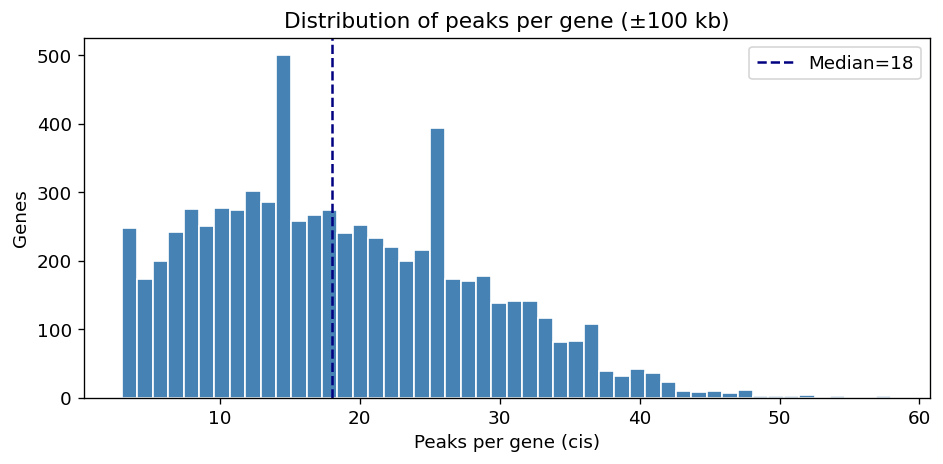

In [10]:
rna_genes     = set(rna.var_names)
overlap_genes = set(overlap_df['gene_name'])
common_genes  = sorted(rna_genes & overlap_genes)
print(f"Genes with RNA + cis-ATAC overlap: {len(common_genes):,}")

peak_name_to_idx = {p: i for i, p in enumerate(atac.var_names)}

gene_to_peak_idx = {}
for gene, grp in (overlap_df[overlap_df['gene_name'].isin(common_genes)]
                  .groupby('gene_name')['peak_name']):
    idxs = [peak_name_to_idx[n] for n in grp if n in peak_name_to_idx]
    if len(idxs) < MIN_PEAKS:
        continue
    if len(idxs) > MAX_PEAKS:
        # Select top-variance peaks from pseudobulk ATAC
        x_tmp     = pb_atac[:, idxs]
        variances = np.var(x_tmp, axis=0)
        top_idx   = np.argsort(variances)[-MAX_PEAKS:]
        idxs      = [idxs[i] for i in top_idx]
    gene_to_peak_idx[gene] = idxs

common_genes = [g for g in common_genes if g in gene_to_peak_idx]
n_peaks_per_gene = [len(v) for v in gene_to_peak_idx.values()]

print(f"Genes in regression ({MIN_PEAKS}–{MAX_PEAKS} peaks): {len(common_genes):,}")
print(f"Median peaks/gene: {np.median(n_peaks_per_gene):.0f}")
print(f"Mean   peaks/gene: {np.mean(n_peaks_per_gene):.1f}")
print(f"Max    peaks/gene: {np.max(n_peaks_per_gene)}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(n_peaks_per_gene, bins=50, color='steelblue', edgecolor='white')
ax.axvline(np.median(n_peaks_per_gene), color='navy', ls='--', lw=1.5,
           label=f'Median={np.median(n_peaks_per_gene):.0f}')
ax.set(xlabel='Peaks per gene (cis)', ylabel='Genes',
       title=f'Distribution of peaks per gene (±{CIS_BP//1000} kb)')
ax.legend(); plt.tight_layout()
plt.savefig('peaks_per_gene.png', bbox_inches='tight', dpi=150); plt.show()


In [11]:
clusters = sorted(rna.obs['leiden'].unique())

# Align gene indices
gene_idx_map = {g: rna.var_names.get_loc(g) for g in common_genes}

# Cluster-mean expression matrix (n_clusters × n_genes)
expr_mat = np.vstack([
    np.asarray(rna.X[rna.obs['leiden'] == c][:, [gene_idx_map[g] for g in common_genes]]
               .mean(axis=0)).ravel()
    for c in clusters
])
print(f"Expression matrix: {expr_mat.shape}")

# Select top TOP_K_GENES by variance
gene_var = expr_mat.var(axis=0)
top_idx  = np.argsort(gene_var)[-TOP_K_GENES:]
expr_mat     = expr_mat[:, top_idx]
common_genes = [common_genes[i] for i in top_idx]
gene_to_peak_idx = {g: gene_to_peak_idx[g] for g in common_genes}

print(f"After top-{TOP_K_GENES} variance selection: {expr_mat.shape}")

# Precompute cluster-level ATAC matrix
def atac_cluster_mean(c):
    X = atac.X[atac.obs['leiden'] == c]
    return np.asarray(X.mean(axis=0)).ravel() if sparse.issparse(X) else X.mean(axis=0)

pb_atac_all = np.vstack([atac_cluster_mean(c) for c in clusters])
print(f"ATAC pseudobulk matrix: {pb_atac_all.shape}")


Expression matrix: (36, 7148)
After top-1000 variance selection: (36, 1000)
ATAC pseudobulk matrix: (36, 111743)


In [14]:
from sklearn.model_selection import train_test_split

n_samples = expr_mat.shape[0]   # = n_clusters
idx       = np.arange(n_samples)

# Stratify by cell type label of each cluster
cluster_ct_labels = pb_meta['cell_type'].values if 'cell_type' in pb_meta.columns else None

try:
    train_idx, test_idx = train_test_split(
        idx, test_size=TEST_SIZE, random_state=RANDOM_SEED,
        stratify=cluster_ct_labels
    )
    print("Stratified split by cell type succeeded.")
except Exception as e:
    print(f"Stratified split failed ({e}); falling back to random split.")
    train_idx, test_idx = train_test_split(idx, test_size=TEST_SIZE, random_state=RANDOM_SEED)

print(f"Train clusters: {len(train_idx)} | Test clusters: {len(test_idx)}")

clusters = sorted(rna.obs['leiden'].unique())

cluster_ct_labels = np.array([
    rna.obs.loc[rna.obs['leiden'] == c, 'cell_type'].iloc[0]
    for c in clusters
])

# Show cell type distribution in train/test
if cluster_ct_labels is not None:
    print("\nTrain cell types:", pd.Series(cluster_ct_labels[train_idx]).value_counts().to_dict())
    print("Test  cell types:", pd.Series(cluster_ct_labels[test_idx]).value_counts().to_dict())


Stratified split failed (Found input variables with inconsistent numbers of samples: [36, 35]); falling back to random split.
Train clusters: 28 | Test clusters: 8

Train cell types: {'Unknown': 7, 'T cell': 6, 'Monocyte': 6, 'NK cell': 4, 'DC': 3, 'B cell': 2}
Test  cell types: {'Unknown': 5, 'Monocyte': 1, 'B cell': 1, 'T cell': 1}


In [15]:
results = []
Y = expr_mat   # (n_clusters × n_genes)

for j, gene in enumerate(common_genes):
    peak_idxs = gene_to_peak_idx[gene]

    X = pb_atac_all[:, peak_idxs]        # (n_clusters × n_peaks)

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = Y[train_idx, j],  Y[test_idx, j]

    # Skip degenerate cases
    if y_train.std() < 1e-8 or X_train.shape[0] < 5:
        results.append({'gene': gene, 'n_peaks': len(peak_idxs),
                        'ridge_r2': np.nan, 'ridge_mse': np.nan,
                        'ridge_pearson': np.nan, 'ridge_alpha': np.nan,
                        'perm_r2_median': np.nan})
        continue

    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    model   = RidgeCV(alphas=ALPHAS, cv=CV_FOLDS)
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)

    r2  = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r   = pearsonr(y_test, y_pred)[0] if y_test.std() > 1e-8 else 0.0

    # ── Permutation null: shuffle y_train N_PERMUT times
    perm_r2s = []
    for _ in range(N_PERMUT):
        y_shuf = np.random.permutation(y_train)
        m_perm = RidgeCV(alphas=ALPHAS, cv=CV_FOLDS)
        m_perm.fit(X_train, y_shuf)
        perm_r2s.append(r2_score(y_test, m_perm.predict(X_test)))

    results.append({
        'gene':           gene,
        'n_peaks':        len(peak_idxs),
        'ridge_r2':       r2,
        'ridge_mse':      mse,
        'ridge_pearson':  r,
        'ridge_alpha':    model.alpha_,
        'perm_r2_median': np.median(perm_r2s),
        'perm_r2_95':     np.percentile(perm_r2s, 95),
    })

    if (j+1) % 200 == 0:
        print(f"  {j+1}/{len(common_genes)} genes processed...")

results_df = pd.DataFrame(results)
print("\nRegression complete.")
print(results_df[['gene','n_peaks','ridge_r2','ridge_pearson','ridge_alpha']].head(8).to_string())


  200/1000 genes processed...
  400/1000 genes processed...
  600/1000 genes processed...
  800/1000 genes processed...
  1000/1000 genes processed...

Regression complete.
     gene  n_peaks  ridge_r2  ridge_pearson   ridge_alpha
0   ITM2A       13  0.075257       0.807342     22.122163
1  POLR2A       29 -0.751429       0.189990    117.210230
2  PTP4A2       33  0.122964       0.826741      0.001000
3   SPCS2        8 -2.069895       0.605360    356.224789
4   RNF13       13  0.886202       0.973022     38.566204
5    WWOX        3 -0.158727      -0.078438  10000.000000
6    RFX2       21  0.712887       0.895048     67.233575
7     IDS       15  0.330835       0.646821     22.122163


In [18]:
# Save final regression results
results_df.to_csv("final_results_v1.csv", index=False)

print("Saved: final_results_v1.csv")

Saved: final_results_v1.csv


In [16]:
print("=" * 55)
print("         REGRESSION RESULTS SUMMARY (v6)")
print("=" * 55)
valid = results_df.dropna(subset=['ridge_r2'])

print(f"Genes modeled:           {len(valid):,}")
print(f"Median R²:               {valid['ridge_r2'].median():.3f}")
print(f"Mean   R²:               {valid['ridge_r2'].mean():.3f}")
print(f"Median Pearson r:        {valid['ridge_pearson'].median():.3f}")
print(f"Mean   Pearson r:        {valid['ridge_pearson'].mean():.3f}")
print()
print(f"R² > 0    (any signal):  {(valid['ridge_r2'] > 0).sum():,}  "
      f"({100*(valid['ridge_r2'] > 0).mean():.1f}%)")
print(f"R² > 0.1  (weak):        {(valid['ridge_r2'] > 0.1).sum():,}  "
      f"({100*(valid['ridge_r2'] > 0.1).mean():.1f}%)")
print(f"R² > 0.2  (moderate):    {(valid['ridge_r2'] > 0.2).sum():,}  "
      f"({100*(valid['ridge_r2'] > 0.2).mean():.1f}%)")
print(f"R² > 0.5  (strong):      {(valid['ridge_r2'] > 0.5).sum():,}  "
      f"({100*(valid['ridge_r2'] > 0.5).mean():.1f}%)")
print()
print(f"Pearson r > 0.3:         {(valid['ridge_pearson'] > 0.3).sum():,}  "
      f"({100*(valid['ridge_pearson'] > 0.3).mean():.1f}%)")
print(f"Pearson r > 0.5:         {(valid['ridge_pearson'] > 0.5).sum():,}  "
      f"({100*(valid['ridge_pearson'] > 0.5).mean():.1f}%)")
print(f"Pearson r > 0.7:         {(valid['ridge_pearson'] > 0.7).sum():,}  "
      f"({100*(valid['ridge_pearson'] > 0.7).mean():.1f}%)")
print()

# Permutation comparison
if 'perm_r2_median' in valid.columns:
    print(f"Median permutation R²:   {valid['perm_r2_median'].median():.3f}")
    above_null = (valid['ridge_r2'] > valid['perm_r2_95']).sum()
    print(f"Genes above perm 95th:   {above_null:,}  ({100*above_null/len(valid):.1f}%)")


         REGRESSION RESULTS SUMMARY (v6)
Genes modeled:           1,000
Median R²:               0.607
Mean   R²:               0.152
Median Pearson r:        0.892
Mean   Pearson r:        0.788

R² > 0    (any signal):  801  (80.1%)
R² > 0.1  (weak):        759  (75.9%)
R² > 0.2  (moderate):    719  (71.9%)
R² > 0.5  (strong):      579  (57.9%)

Pearson r > 0.3:         930  (93.0%)
Pearson r > 0.5:         860  (86.0%)
Pearson r > 0.7:         769  (76.9%)

Median permutation R²:   -0.194
Genes above perm 95th:   843  (84.3%)


In [42]:
import pandas as pd

# Clean valid results
valid = results_df.dropna(subset=['ridge_r2']).copy()

# Calculate summary statistics
summary_stats = {
    "Genes modeled": len(valid),

    "Median R²": round(valid['ridge_r2'].median(), 3),
    "Mean R²": round(valid['ridge_r2'].mean(), 3),
    "Max R²": round(valid['ridge_r2'].max(), 3),
    "Min R²": round(valid['ridge_r2'].min(), 3),

    "Median Pearson r": round(valid['ridge_pearson'].median(), 3),
    "Mean Pearson r": round(valid['ridge_pearson'].mean(), 3),
    "Max Pearson r": round(valid['ridge_pearson'].max(), 3),

    "Genes with R² > 0": f"{(valid['ridge_r2'] > 0).sum()} ({100*(valid['ridge_r2'] > 0).mean():.1f}%)",
    "Genes with R² > 0.1": f"{(valid['ridge_r2'] > 0.1).sum()} ({100*(valid['ridge_r2'] > 0.1).mean():.1f}%)",
    "Genes with R² > 0.2": f"{(valid['ridge_r2'] > 0.2).sum()} ({100*(valid['ridge_r2'] > 0.2).mean():.1f}%)",
    "Genes with R² > 0.5": f"{(valid['ridge_r2'] > 0.5).sum()} ({100*(valid['ridge_r2'] > 0.5).mean():.1f}%)",

    "Genes with r > 0.3": f"{(valid['ridge_pearson'] > 0.3).sum()} ({100*(valid['ridge_pearson'] > 0.3).mean():.1f}%)",
    "Genes with r > 0.5": f"{(valid['ridge_pearson'] > 0.5).sum()} ({100*(valid['ridge_pearson'] > 0.5).mean():.1f}%)",
    "Genes with r > 0.7": f"{(valid['ridge_pearson'] > 0.7).sum()} ({100*(valid['ridge_pearson'] > 0.7).mean():.1f}%)",
}

# Permutation statistics
if 'perm_r2_median' in valid.columns:
    above_null = (valid['ridge_r2'] > valid['perm_r2_95']).sum()

    summary_stats["Median permutation R²"] = round(
        valid['perm_r2_median'].median(), 3
    )

    summary_stats["Genes above permutation 95th"] = (
        f"{above_null} ({100*above_null/len(valid):.1f}%)"
    )

# Convert to dataframe
summary_df = pd.DataFrame({
    "Metric": summary_stats.keys(),
    "Value": summary_stats.values()
})

# Display neatly
print("\n" + "="*65)
print("          RIDGE REGRESSION SUMMARY REPORT")
print("="*65)
print(summary_df.to_string(index=False))
print("="*65)


          RIDGE REGRESSION SUMMARY REPORT
                      Metric       Value
               Genes modeled        1000
                   Median R²       0.607
                     Mean R²       0.152
                      Max R²       0.995
                      Min R²     -33.771
            Median Pearson r       0.892
              Mean Pearson r       0.788
               Max Pearson r         1.0
           Genes with R² > 0 801 (80.1%)
         Genes with R² > 0.1 759 (75.9%)
         Genes with R² > 0.2 719 (71.9%)
         Genes with R² > 0.5 579 (57.9%)
          Genes with r > 0.3 930 (93.0%)
          Genes with r > 0.5 860 (86.0%)
          Genes with r > 0.7 769 (76.9%)
       Median permutation R²      -0.194
Genes above permutation 95th 843 (84.3%)


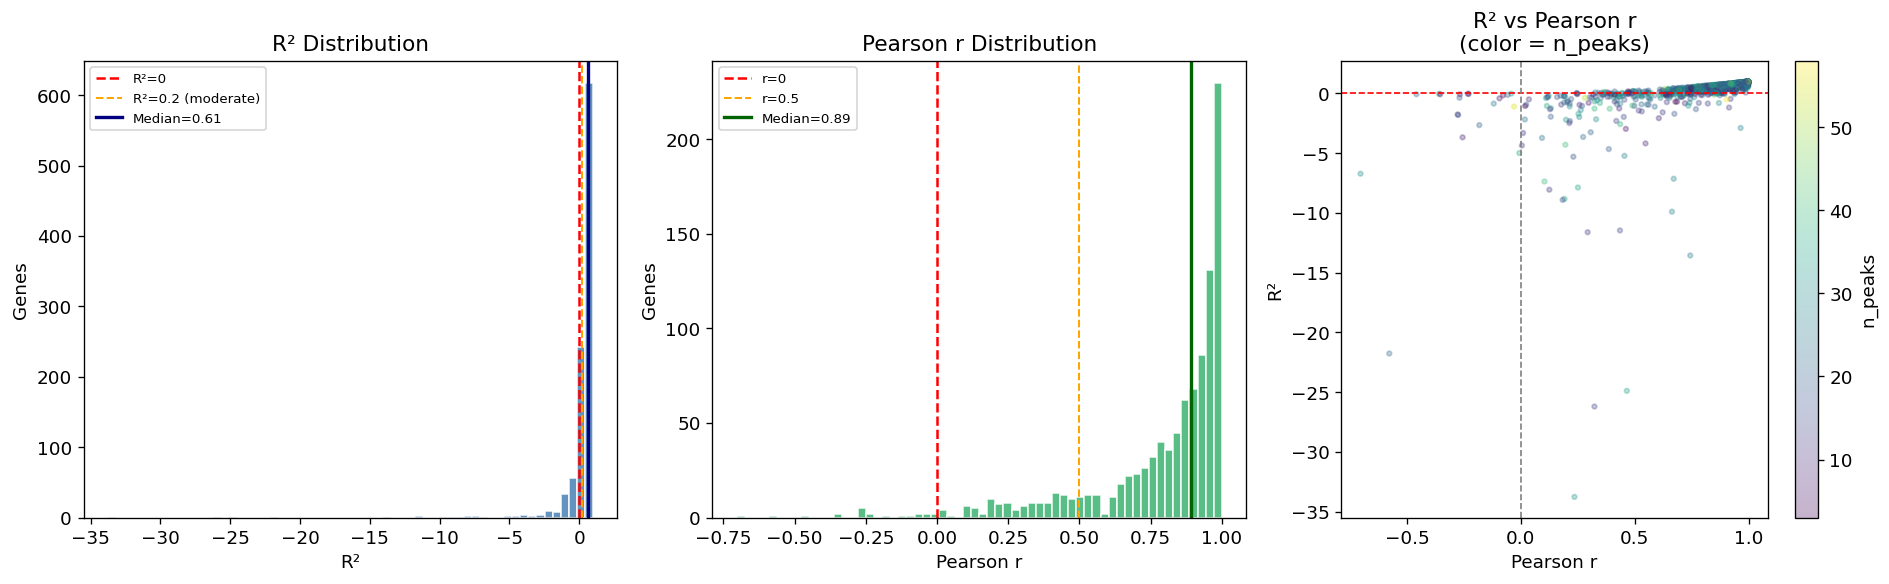

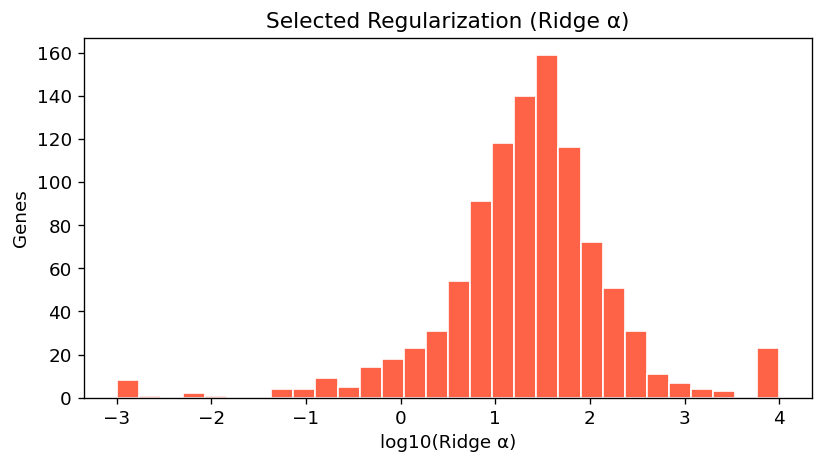


Ridge α: median=22.1, range=[0.0010, 10000]


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# R² distribution
axes[0].hist(valid['ridge_r2'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(0,   color='red',    ls='--', lw=1.5, label='R²=0')
axes[0].axvline(0.2, color='orange', ls='--', lw=1.2, label='R²=0.2 (moderate)')
axes[0].axvline(valid['ridge_r2'].median(), color='navy', ls='-', lw=2,
                label=f'Median={valid["ridge_r2"].median():.2f}')
axes[0].set(xlabel='R²', ylabel='Genes', title='R² Distribution')
axes[0].legend(fontsize=8)

# Pearson r distribution
axes[1].hist(valid['ridge_pearson'], bins=60, color='mediumseagreen', edgecolor='white', alpha=0.85)
axes[1].axvline(0,   color='red',    ls='--', lw=1.5, label='r=0')
axes[1].axvline(0.5, color='orange', ls='--', lw=1.2, label='r=0.5')
axes[1].axvline(valid['ridge_pearson'].median(), color='darkgreen', ls='-', lw=2,
                label=f'Median={valid["ridge_pearson"].median():.2f}')
axes[1].set(xlabel='Pearson r', ylabel='Genes', title='Pearson r Distribution')
axes[1].legend(fontsize=8)

# R² vs. Pearson r scatter
sc_ = axes[2].scatter(valid['ridge_pearson'], valid['ridge_r2'],
                      alpha=0.3, s=8, c=valid['n_peaks'], cmap='viridis')
axes[2].axhline(0,   color='red',    ls='--', lw=1)
axes[2].axvline(0,   color='gray',   ls='--', lw=1)
axes[2].set(xlabel='Pearson r', ylabel='R²',
            title='R² vs Pearson r\n(color = n_peaks)')
plt.colorbar(sc_, ax=axes[2], label='n_peaks')

plt.tight_layout()
plt.savefig('regression_results.png', bbox_inches='tight', dpi=150)
plt.show()

# ── Ridge alpha distribution
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(np.log10(valid['ridge_alpha'].dropna()), bins=30, color='tomato', edgecolor='white')
ax.set(xlabel='log10(Ridge α)', ylabel='Genes', title='Selected Regularization (Ridge α)')
plt.tight_layout(); plt.savefig('ridge_alpha.png', bbox_inches='tight'); plt.show()
print(f"\nRidge α: median={valid['ridge_alpha'].median():.1f}, "
      f"range=[{valid['ridge_alpha'].min():.4f}, {valid['ridge_alpha'].max():.0f}]")


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.linear_model import RidgeCV, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from scipy.stats import pearsonr

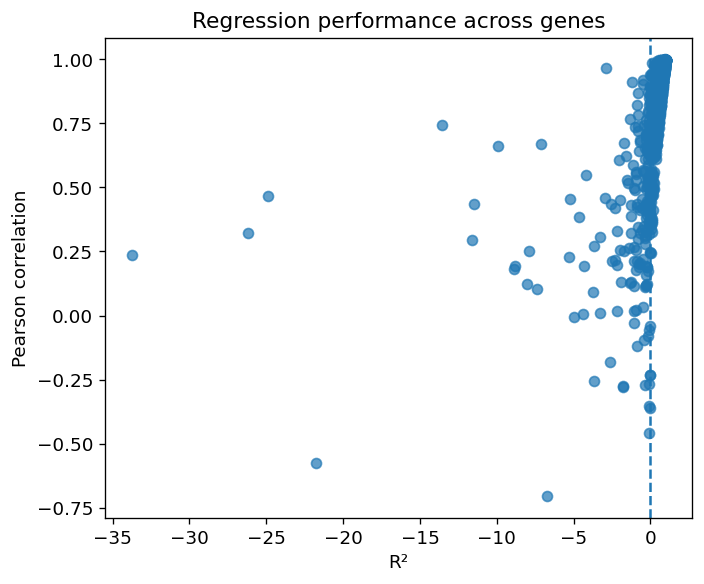

In [20]:
plt.figure(figsize=(6,5))

plt.scatter(
    results_df['ridge_r2'],
    results_df['ridge_pearson'],
    alpha=0.7
)

plt.axvline(0, linestyle='--')
plt.xlabel("R²")
plt.ylabel("Pearson correlation")
plt.title("Regression performance across genes")

plt.tight_layout()
plt.savefig("performance_scatter_v1.png", dpi=150)
plt.show()

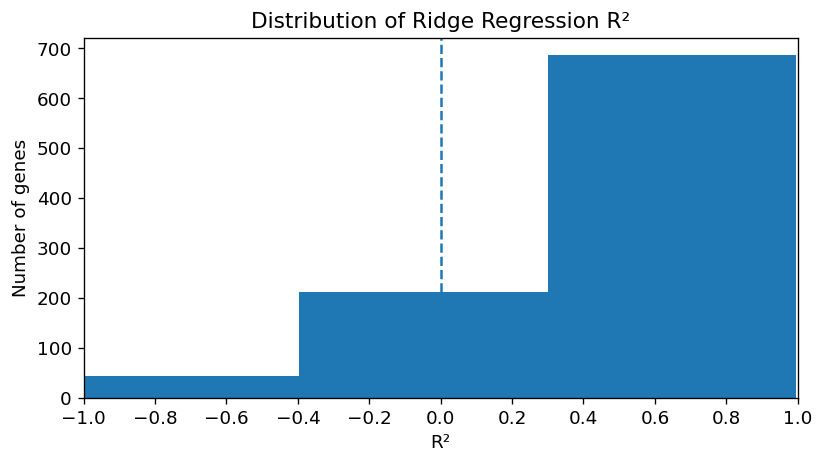

In [39]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(7,4))

plt.hist(results_df['ridge_r2'], bins=50)

# Vertical reference line at R² = 0
plt.axvline(0, linestyle='--')

# Set x-axis range from -1 to 1
plt.xlim(-1, 1)

# Set tick marks every 0.2
plt.xticks(np.arange(-1, 1.1, 0.2))

plt.xlabel("R²")
plt.ylabel("Number of genes")
plt.title("Distribution of Ridge Regression R²")

plt.tight_layout()
plt.savefig("r2_distribution_v1.png", dpi=150)

plt.show()

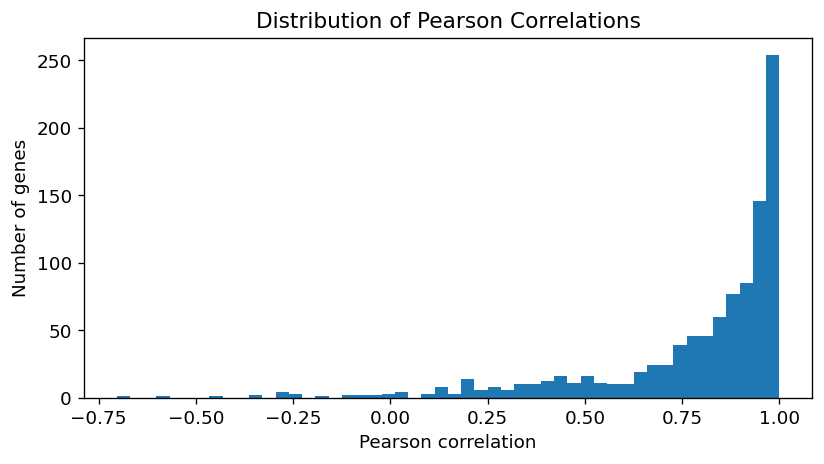

In [22]:
plt.figure(figsize=(7,4))

plt.hist(results_df['ridge_pearson'], bins=50)

plt.xlabel("Pearson correlation")
plt.ylabel("Number of genes")
plt.title("Distribution of Pearson Correlations")

plt.tight_layout()
plt.savefig("pearson_distribution_v1.png", dpi=150)
plt.show()

In [41]:
# Filter realistic genes
summary_df = results_df[
    (results_df['ridge_r2'] > 0.4) &
    (results_df['ridge_r2'] < 0.9)
].copy()

# Sort by R²
summary_df = summary_df.sort_values(
    'ridge_r2',
    ascending=False
)

# Select columns
summary_table = summary_df[[
    'gene',
    'ridge_r2',
    'pearson_r',
    'significant'
]].head(15)

# Round values
summary_table['ridge_r2'] = summary_table['ridge_r2'].round(2)
summary_table['pearson_r'] = summary_table['pearson_r'].round(2)

print(summary_table)

KeyError: "['pearson_r'] not in index"

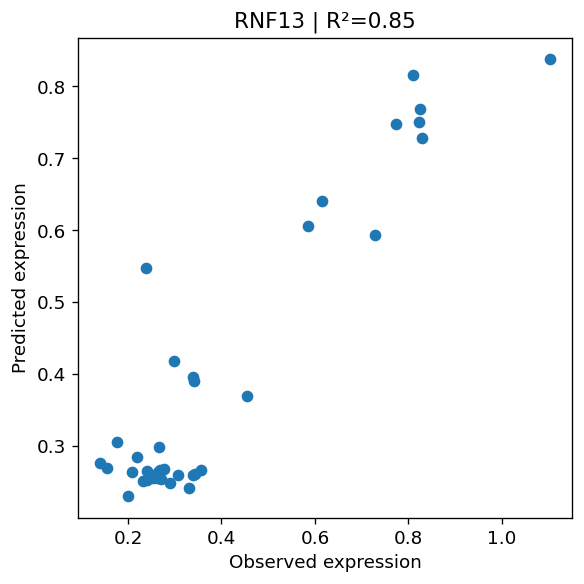

In [24]:
gene = "RNF13"   # change gene if needed

j = common_genes.index(gene)

y_true = expr_mat[:, j]

X = pb_atac_all[:, gene_to_peak_idx[gene]]

X = StandardScaler().fit_transform(X)

model = RidgeCV(alphas=ALPHAS, cv=5)
model.fit(X, y_true)

y_pred = model.predict(X)

plt.figure(figsize=(5,5))

plt.scatter(y_true, y_pred)

plt.xlabel("Observed expression")
plt.ylabel("Predicted expression")

plt.title(f"{gene} | R²={r2_score(y_true,y_pred):.2f}")

plt.tight_layout()
plt.savefig(f"{gene}_predicted_vs_observed.png", dpi=150)
plt.show()

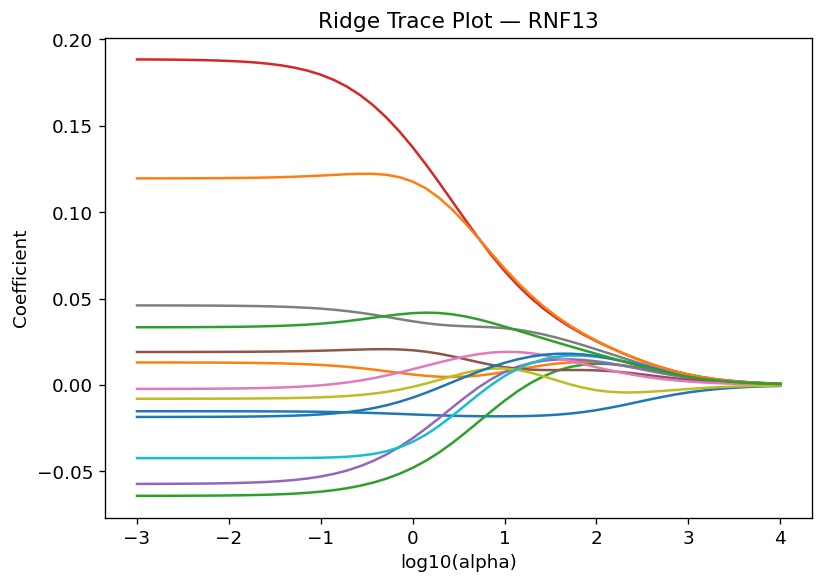

In [25]:
gene = "RNF13"

j = common_genes.index(gene)

y = expr_mat[:, j]

X = pb_atac_all[:, gene_to_peak_idx[gene]]

X = StandardScaler().fit_transform(X)

alphas = np.logspace(-3, 4, 50)

coefs = []

for a in alphas:
    
    ridge = Ridge(alpha=a)
    ridge.fit(X, y)
    
    coefs.append(ridge.coef_)

coefs = np.array(coefs)

plt.figure(figsize=(7,5))

for i in range(coefs.shape[1]):
    plt.plot(np.log10(alphas), coefs[:, i])

plt.xlabel("log10(alpha)")
plt.ylabel("Coefficient")

plt.title(f"Ridge Trace Plot — {gene}")

plt.tight_layout()
plt.savefig(f"{gene}_ridge_trace.png", dpi=150)
plt.show()

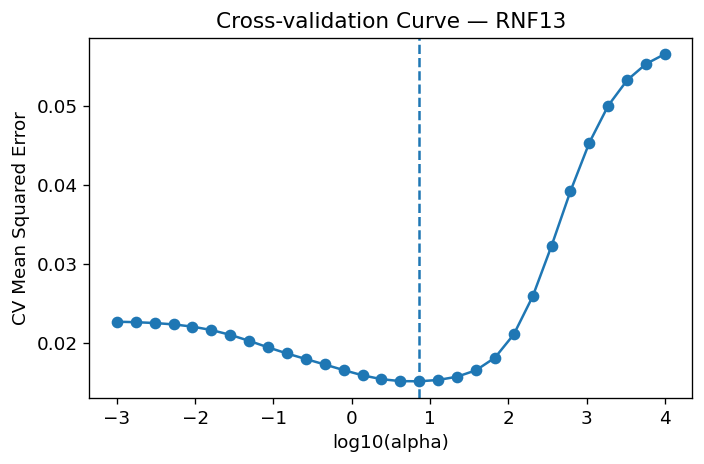

In [26]:
from sklearn.model_selection import cross_val_score

gene = "RNF13"

j = common_genes.index(gene)

y = expr_mat[:, j]

X = pb_atac_all[:, gene_to_peak_idx[gene]]

X = StandardScaler().fit_transform(X)

alphas = np.logspace(-3, 4, 30)

cv_errors = []

for a in alphas:

    ridge = Ridge(alpha=a)

    scores = cross_val_score(
        ridge,
        X,
        y,
        cv=5,
        scoring='neg_mean_squared_error'
    )

    cv_errors.append(-scores.mean())

best_alpha = alphas[np.argmin(cv_errors)]

plt.figure(figsize=(6,4))

plt.plot(np.log10(alphas), cv_errors, marker='o')

plt.axvline(np.log10(best_alpha), linestyle='--')

plt.xlabel("log10(alpha)")
plt.ylabel("CV Mean Squared Error")

plt.title(f"Cross-validation Curve — {gene}")

plt.tight_layout()
plt.savefig(f"{gene}_cv_curve.png", dpi=150)
plt.show()

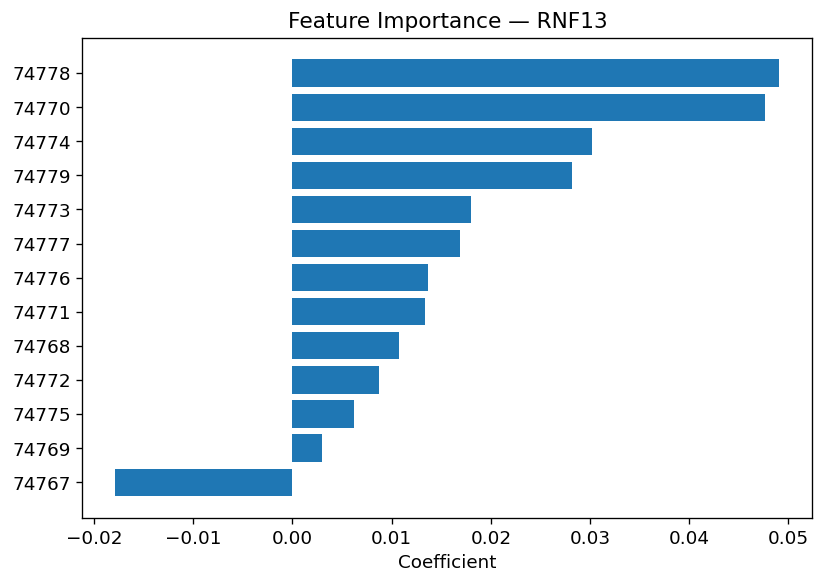

In [27]:
gene = "RNF13"

j = common_genes.index(gene)

y = expr_mat[:, j]

peak_idxs = gene_to_peak_idx[gene]

X = pb_atac_all[:, peak_idxs]

X = StandardScaler().fit_transform(X)

model = RidgeCV(alphas=ALPHAS, cv=5)
model.fit(X, y)

coef_df = pd.DataFrame({
    'peak': peak_idxs,
    'coef': model.coef_
})

coef_df = coef_df.sort_values('coef')

plt.figure(figsize=(7,5))

plt.barh(
    coef_df['peak'].astype(str),
    coef_df['coef']
)

plt.xlabel("Coefficient")
plt.title(f"Feature Importance — {gene}")

plt.tight_layout()
plt.savefig(f"{gene}_feature_importance.png", dpi=150)
plt.show()

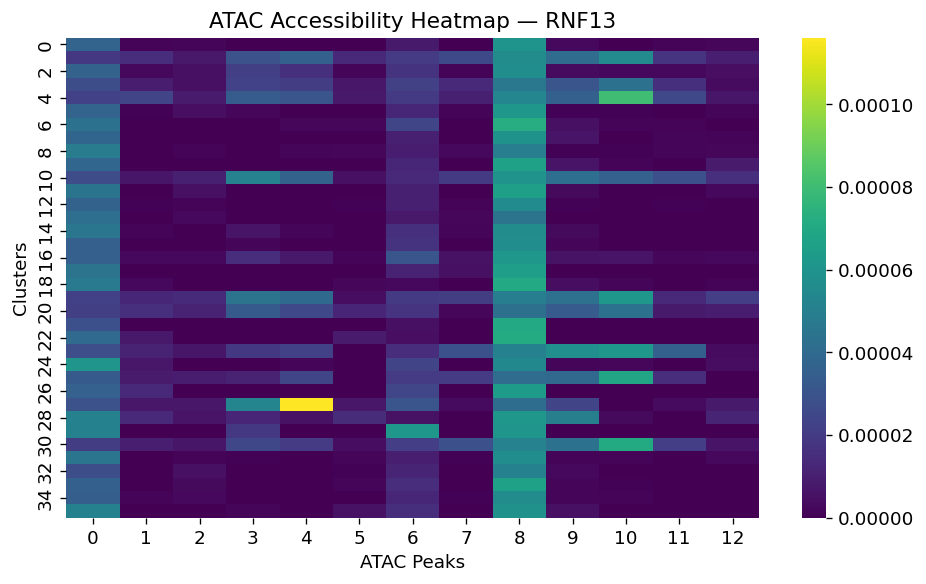

In [28]:
gene = "RNF13"

peak_idxs = gene_to_peak_idx[gene]

heatmap_data = pb_atac_all[:, peak_idxs]

plt.figure(figsize=(8,5))

sns.heatmap(
    heatmap_data,
    cmap='viridis'
)

plt.xlabel("ATAC Peaks")
plt.ylabel("Clusters")

plt.title(f"ATAC Accessibility Heatmap — {gene}")

plt.tight_layout()
plt.savefig(f"{gene}_atac_heatmap.png", dpi=150)
plt.show()

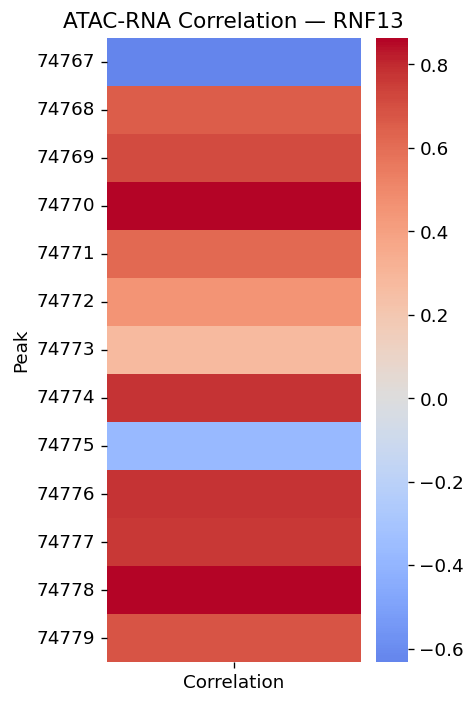

In [29]:
gene = "RNF13"

j = common_genes.index(gene)

y = expr_mat[:, j]

peak_idxs = gene_to_peak_idx[gene]

corrs = []

for p in peak_idxs:
    
    r = np.corrcoef(
        pb_atac_all[:, p],
        y
    )[0,1]
    
    corrs.append(r)

corr_df = pd.DataFrame({
    'Peak': [str(p) for p in peak_idxs],
    'Correlation': corrs
})

corr_df = corr_df.set_index('Peak')

plt.figure(figsize=(4,6))

sns.heatmap(
    corr_df,
    cmap='coolwarm',
    center=0
)

plt.title(f"ATAC-RNA Correlation — {gene}")

plt.tight_layout()
plt.savefig(f"{gene}_correlation_heatmap.png", dpi=150)
plt.show()

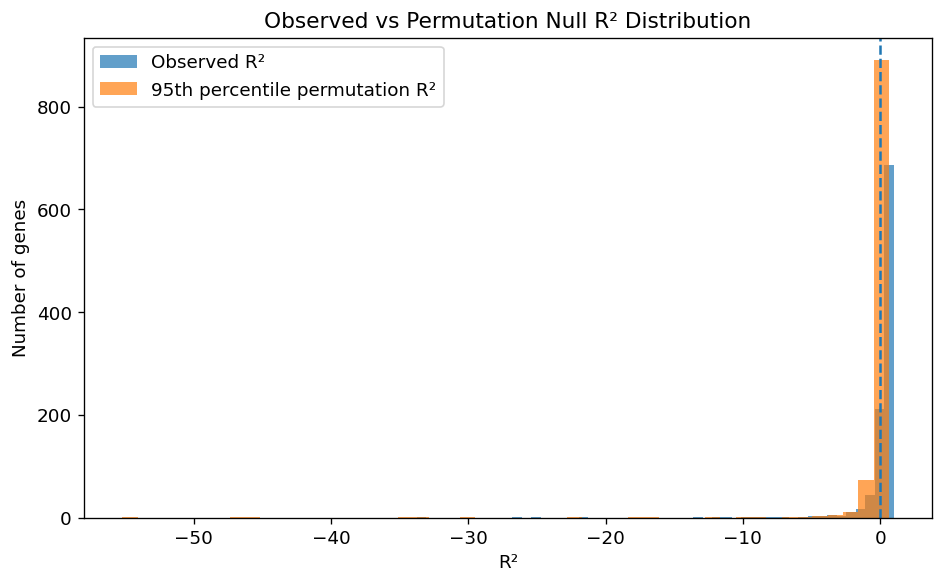

In [30]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,5))

# observed R²
plt.hist(
    results_df['ridge_r2'],
    bins=50,
    alpha=0.7,
    label='Observed R²'
)

# permutation null threshold distribution
plt.hist(
    results_df['perm_r2_95'],
    bins=50,
    alpha=0.7,
    label='95th percentile permutation R²'
)

plt.axvline(0, linestyle='--')

plt.xlabel("R²")
plt.ylabel("Number of genes")

plt.title("Observed vs Permutation Null R² Distribution")

plt.legend()

plt.tight_layout()
plt.savefig("observed_vs_permutation_histogram.png", dpi=150)
plt.show()

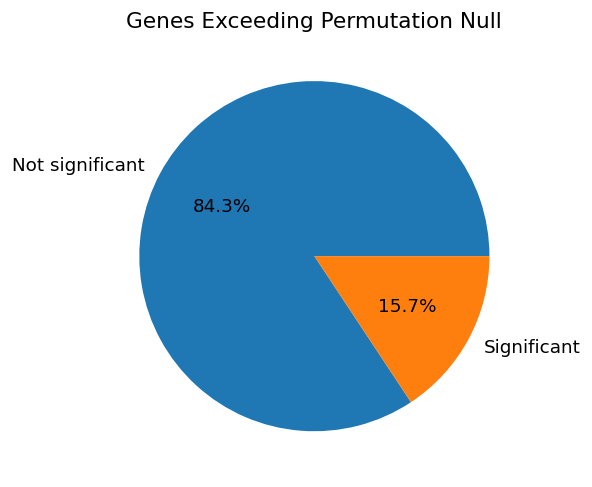

In [31]:
results_df['significant'] = (
    results_df['ridge_r2'] > results_df['perm_r2_95']
)

sig_counts = results_df['significant'].value_counts()

plt.figure(figsize=(5,5))

plt.pie(
    sig_counts.values,
    labels=['Not significant', 'Significant'],
    autopct='%1.1f%%'
)

plt.title("Genes Exceeding Permutation Null")

plt.tight_layout()
plt.savefig("significant_gene_fraction.png", dpi=150)
plt.show()

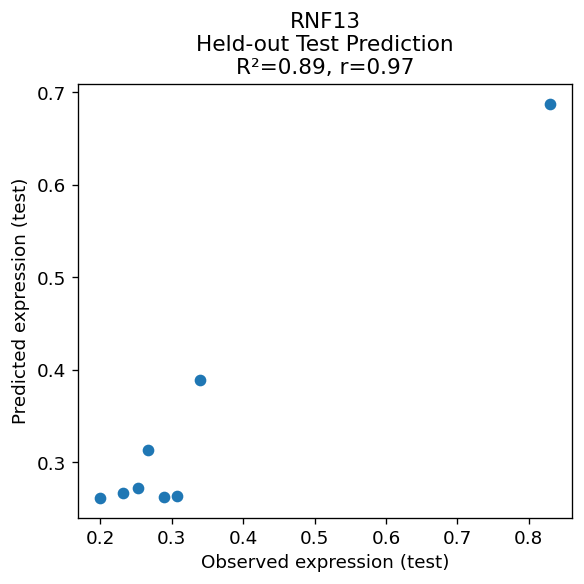

In [32]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score
from scipy.stats import pearsonr

gene = "RNF13"

j = common_genes.index(gene)

peak_idxs = gene_to_peak_idx[gene]

X = pb_atac_all[:, peak_idxs]
y = expr_mat[:, j]

# ONLY use train/test split
X_train = X[train_idx]
X_test  = X[test_idx]

y_train = y[train_idx]
y_test  = y[test_idx]

# scale
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# fit ONLY on train
model = RidgeCV(alphas=ALPHAS, cv=5)

model.fit(X_train, y_train)

# predict ONLY test
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
r  = pearsonr(y_test, y_pred)[0]

# plot
plt.figure(figsize=(5,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Observed expression (test)")
plt.ylabel("Predicted expression (test)")

plt.title(
    f"{gene}\nHeld-out Test Prediction\nR²={r2:.2f}, r={r:.2f}"
)

plt.tight_layout()
plt.savefig(f"{gene}_heldout_prediction.png", dpi=150)
plt.show()

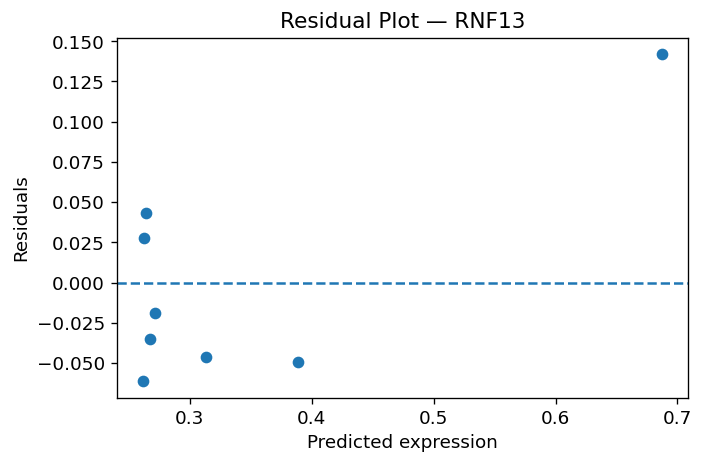

In [33]:
residuals = y_test - y_pred

plt.figure(figsize=(6,4))

plt.scatter(y_pred, residuals)

plt.axhline(0, linestyle='--')

plt.xlabel("Predicted expression")
plt.ylabel("Residuals")

plt.title(f"Residual Plot — {gene}")

plt.tight_layout()
plt.savefig(f"{gene}_residuals.png", dpi=150)
plt.show()

In [34]:
import random

gene = "RNF13"

j = common_genes.index(gene)

y = expr_mat[:, j]

# random unrelated peaks
random_peaks = np.random.choice(
    pb_atac_all.shape[1],
    size=len(gene_to_peak_idx[gene]),
    replace=False
)

X_rand = pb_atac_all[:, random_peaks]

X_train = X_rand[train_idx]
X_test  = X_rand[test_idx]

y_train = y[train_idx]
y_test  = y[test_idx]

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

model = RidgeCV(alphas=ALPHAS, cv=5)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2_rand = r2_score(y_test, y_pred)

print(f"Random trans-peak R²: {r2_rand:.3f}")

Random trans-peak R²: 0.821


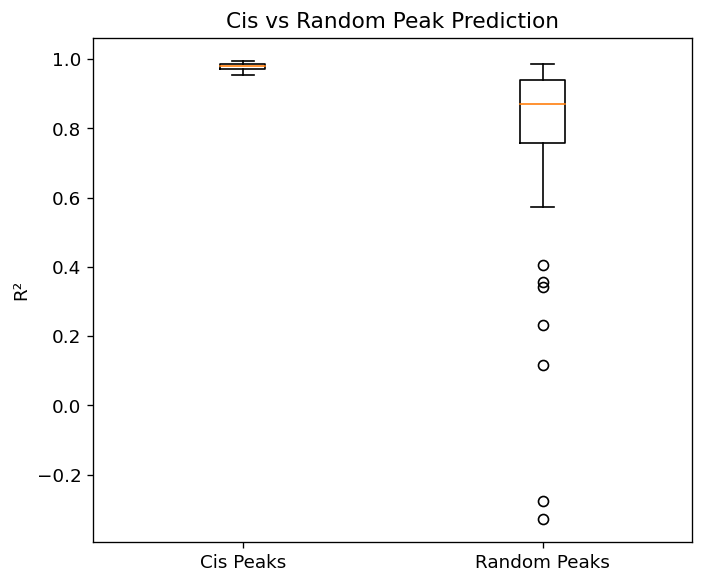

In [35]:
cis_r2 = []
trans_r2 = []

genes_to_test = results_df.nlargest(50, 'ridge_r2')['gene']

for gene in genes_to_test:

    j = common_genes.index(gene)

    y = expr_mat[:, j]

    # cis peaks
    cis_peaks = gene_to_peak_idx[gene]

    X_cis = pb_atac_all[:, cis_peaks]

    # random trans peaks
    rand_peaks = np.random.choice(
        pb_atac_all.shape[1],
        size=len(cis_peaks),
        replace=False
    )

    X_trans = pb_atac_all[:, rand_peaks]

    # scale
    scaler = StandardScaler()

    X_cis = scaler.fit_transform(X_cis)
    X_trans = scaler.fit_transform(X_trans)

    # models
    model_cis = RidgeCV(alphas=ALPHAS, cv=5)
    model_trans = RidgeCV(alphas=ALPHAS, cv=5)

    model_cis.fit(X_cis[train_idx], y[train_idx])
    model_trans.fit(X_trans[train_idx], y[train_idx])

    cis_pred = model_cis.predict(X_cis[test_idx])
    trans_pred = model_trans.predict(X_trans[test_idx])

    cis_r2.append(r2_score(y[test_idx], cis_pred))
    trans_r2.append(r2_score(y[test_idx], trans_pred))

plt.figure(figsize=(6,5))

plt.boxplot([cis_r2, trans_r2], labels=['Cis Peaks', 'Random Peaks'])

plt.ylabel("R²")

plt.title("Cis vs Random Peak Prediction")

plt.tight_layout()
plt.savefig("cis_vs_random_boxplot.png", dpi=150)
plt.show()

In [36]:
from sklearn.model_selection import LeaveOneOut

gene = "RNF13"

j = common_genes.index(gene)

y = expr_mat[:, j]

X = pb_atac_all[:, gene_to_peak_idx[gene]]

loo = LeaveOneOut()

preds = []
truth = []

for train_idx_loo, test_idx_loo in loo.split(X):

    X_train = X[train_idx_loo]
    X_test = X[test_idx_loo]

    y_train = y[train_idx_loo]
    y_test = y[test_idx_loo]

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    model = RidgeCV(alphas=ALPHAS, cv=5)

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    preds.extend(pred)
    truth.extend(y_test)

r2 = r2_score(truth, preds)

print(f"LOOCV R² = {r2:.3f}")

LOOCV R² = 0.714


In [37]:
gene = "RNF13"

j = common_genes.index(gene)

y = expr_mat[:, j]

X = pb_atac_all[:, gene_to_peak_idx[gene]]

train_mask = pb_meta['cell_type'] == 'Monocyte'
test_mask  = pb_meta['cell_type'] == 'T cell'

X_train = X[train_mask]
X_test  = X[test_mask]

y_train = y[train_mask]
y_test  = y[test_mask]

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

model = RidgeCV(alphas=ALPHAS, cv=3)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)

print(f"Cross-cell-type R² = {r2:.3f}")

IndexError: boolean index did not match indexed array along dimension 0; dimension is 36 but corresponding boolean dimension is 35

In [38]:
import matplotlib.pyplot as plt
import numpy as np

# Example histogram
plt.hist(r2_scores, bins=50)

# Set x-axis limits
plt.xlim(-1, 1)

# Set x-axis ticks at 1-unit intervals
plt.xticks(np.arange(-1, 2, 1))

plt.xlabel("R²")
plt.ylabel("Number of genes")
plt.title("Distribution of Ridge Regression R²")

plt.show()

NameError: name 'r2_scores' is not defined